# claude-code-api — Latency Benchmark

Runs all timing scenarios against the local API and displays results inline.  
No files are written. Re-run any cell to refresh.

In [1]:
import json
import time

import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import display

BASE_URL = "http://localhost:8731"
QUERY_URL = f"{BASE_URL}/query"
HEALTH_URL = f"{BASE_URL}/health"

In [2]:
# -------------------------------------------------------------------------------------
# ----------------------------------- scenarios ---------------------------------------
# -------------------------------------------------------------------------------------

SHORT_TEXT = "The quick brown fox jumps over the lazy dog."

MEDIUM_TEXT = " ".join(
    [
        "Artificial intelligence has transformed the way we interact with technology.",
        "Machine learning models can now perform tasks that once required human intelligence.",
        "Natural language processing allows computers to understand and generate human text.",
        "Deep learning architectures have enabled breakthroughs in image recognition and speech.",
        "Reinforcement learning allows agents to learn optimal behaviour through trial and error.",
        "Transfer learning lets pre-trained models be fine-tuned for specific downstream tasks.",
        "Attention mechanisms in transformers revolutionised sequence modelling tasks.",
        "Large language models are trained on vast corpora of text from the internet.",
        "Prompt engineering is the art of crafting inputs that elicit desired model outputs.",
        "Retrieval-augmented generation combines parametric and non-parametric knowledge.",
    ]
    * 5
)

LONG_TEXT = " ".join(
    [
        "In the rapidly evolving landscape of artificial intelligence, large language models have "
        "emerged as a transformative technology with far-reaching implications across virtually every "
        "domain of human activity. These models, trained on vast corpora of text data encompassing "
        "billions of words from books, websites, scientific papers, and code repositories, have "
        "demonstrated remarkable capabilities in understanding context, generating coherent prose, "
        "reasoning through complex problems, and adapting to diverse tasks with minimal additional "
        "guidance. The architecture underlying these systems, based on the transformer model "
        "introduced by Vaswani et al. in 2017, relies on self-attention mechanisms that allow the "
        "model to weigh the relevance of different tokens when producing each output. Training such "
        "models requires enormous computational resources, typically thousands of specialised "
        "accelerators running for weeks or months, consuming energy equivalent to the lifetime "
        "emissions of several automobiles. Despite these costs, the resulting systems exhibit "
        "emergent capabilities that were not explicitly trained for, including multi-step reasoning, "
        "analogy-making, and rudimentary common-sense inference. The deployment of these models "
        "raises profound questions about intellectual property, bias amplification, environmental "
        "impact, economic displacement, and the nature of intelligence itself."
    ]
    * 10
)

CODE_CONTEXT = (
    """
def binary_search(arr, target):
    left, right = 0, len(arr) - 1
    while left <= right:
        mid = (left + right) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            left = mid + 1
        else:
            right = mid - 1
    return -1

def merge_sort(arr):
    if len(arr) <= 1:
        return arr
    mid = len(arr) // 2
    left = merge_sort(arr[:mid])
    right = merge_sort(arr[mid:])
    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result
"""
    * 3
)

SYSTEM_SHORT = "You are a helpful assistant. Answer concisely."

SYSTEM_LONG = (
    "You are an expert software engineer, technical writer, and educator with 20 years of "
    "experience across systems programming, distributed systems, machine learning infrastructure, "
    "and developer tooling. You provide precise, accurate, and well-reasoned answers. You always "
    "cite trade-offs, acknowledge uncertainty, and tailor your explanations to the technical level "
    "implied by the question. You prefer code examples over abstract descriptions. You never "
    "hallucinate library APIs or invent facts. When asked to review code you are thorough, "
    "constructive, and specific. When asked to write code you produce idiomatic, well-commented, "
    "production-quality output."
)

SCENARIOS = [
    # --- tiny prompt, short answer ---
    {"name": "tiny_haiku",   "model": "fast",     "prompt": "What is 2 + 2?", "system": None,         "max_tokens": 32,   "tags": ["tiny"]},
    {"name": "tiny_sonnet",  "model": "balanced", "prompt": "What is 2 + 2?", "system": None,         "max_tokens": 32,   "tags": ["tiny"]},
    {"name": "tiny_opus",    "model": "best",      "prompt": "What is 2 + 2?", "system": None,         "max_tokens": 32,   "tags": ["tiny"]},
    # --- short context ---
    {"name": "short_haiku",  "model": "fast",     "prompt": f"Summarise in one sentence: {SHORT_TEXT}", "system": SYSTEM_SHORT, "max_tokens": 64,  "tags": ["short_ctx"]},
    {"name": "short_sonnet", "model": "balanced", "prompt": f"Summarise in one sentence: {SHORT_TEXT}", "system": SYSTEM_SHORT, "max_tokens": 64,  "tags": ["short_ctx"]},
    {"name": "short_opus",   "model": "best",      "prompt": f"Summarise in one sentence: {SHORT_TEXT}", "system": SYSTEM_SHORT, "max_tokens": 64,  "tags": ["short_ctx"]},
    # --- medium context ---
    {"name": "medium_haiku",  "model": "fast",     "prompt": f"Summarise in 3-4 sentences:\n\n{MEDIUM_TEXT}", "system": SYSTEM_SHORT, "max_tokens": 256, "tags": ["medium_ctx"]},
    {"name": "medium_sonnet", "model": "balanced", "prompt": f"Summarise in 3-4 sentences:\n\n{MEDIUM_TEXT}", "system": SYSTEM_SHORT, "max_tokens": 256, "tags": ["medium_ctx"]},
    {"name": "medium_opus",   "model": "best",      "prompt": f"Summarise in 3-4 sentences:\n\n{MEDIUM_TEXT}", "system": SYSTEM_SHORT, "max_tokens": 256, "tags": ["medium_ctx"]},
    # --- long context ---
    {"name": "long_haiku",  "model": "fast",     "prompt": f"Extract the three most important themes:\n\n{LONG_TEXT}", "system": SYSTEM_LONG, "max_tokens": 512, "tags": ["long_ctx"]},
    {"name": "long_sonnet", "model": "balanced", "prompt": f"Extract the three most important themes:\n\n{LONG_TEXT}", "system": SYSTEM_LONG, "max_tokens": 512, "tags": ["long_ctx"]},
    {"name": "long_opus",   "model": "best",      "prompt": f"Extract the three most important themes:\n\n{LONG_TEXT}", "system": SYSTEM_LONG, "max_tokens": 512, "tags": ["long_ctx"]},
    # --- code context ---
    {"name": "code_haiku",  "model": "fast",     "prompt": f"Review this Python code for bugs and style issues:\n\n{CODE_CONTEXT}", "system": SYSTEM_LONG, "max_tokens": 512, "tags": ["code_ctx"]},
    {"name": "code_sonnet", "model": "balanced", "prompt": f"Review this Python code for bugs and style issues:\n\n{CODE_CONTEXT}", "system": SYSTEM_LONG, "max_tokens": 512, "tags": ["code_ctx"]},
    {"name": "code_opus",   "model": "best",      "prompt": f"Review this Python code for bugs and style issues:\n\n{CODE_CONTEXT}", "system": SYSTEM_LONG, "max_tokens": 512, "tags": ["code_ctx"]},
    # --- long output ---
    {"name": "long_out_haiku",  "model": "fast",     "prompt": "Write a detailed 500-word essay on the history of the internet.", "system": SYSTEM_SHORT, "max_tokens": 1024, "tags": ["long_output"]},
    {"name": "long_out_sonnet", "model": "balanced", "prompt": "Write a detailed 500-word essay on the history of the internet.", "system": SYSTEM_SHORT, "max_tokens": 1024, "tags": ["long_output"]},
    {"name": "long_out_opus",   "model": "best",      "prompt": "Write a detailed 500-word essay on the history of the internet.", "system": SYSTEM_SHORT, "max_tokens": 1024, "tags": ["long_output"]},
]

In [3]:
# -------------------------------------------------------------------------------------
# ----------------------------------- runner ------------------------------------------
# -------------------------------------------------------------------------------------

def run_scenario(s: dict) -> dict:
    payload = {"prompt": s["prompt"], "model": s["model"], "max_tokens": s["max_tokens"]}
    if s.get("system"):
        payload["system"] = s["system"]

    t0 = time.perf_counter()
    try:
        resp = requests.post(QUERY_URL, json=payload, timeout=300)
        resp.raise_for_status()
        data = resp.json()
        wall_ms = (time.perf_counter() - t0) * 1000
        return {
            "name": s["name"], "model": s["model"], "tags": s["tags"],
            "prompt_chars": len(s["prompt"]), "system_chars": len(s.get("system") or ""),
            "wall_ms": round(wall_ms, 1),
            "reported_ms": data.get("duration_ms"),
            "response_chars": len(data.get("response", "")),
            "response": data.get("response", ""),
            "status": "ok", "error": None,
        }
    except Exception as exc:
        wall_ms = (time.perf_counter() - t0) * 1000
        return {
            "name": s["name"], "model": s["model"], "tags": s["tags"],
            "prompt_chars": len(s["prompt"]), "system_chars": len(s.get("system") or ""),
            "wall_ms": round(wall_ms, 1), "reported_ms": None,
            "response_chars": 0, "response": "",
            "status": "error", "error": str(exc),
        }


health = requests.get(HEALTH_URL, timeout=10).json()
print(f"Health: {json.dumps(health, indent=2)}\n")

results = []
for i, s in enumerate(SCENARIOS, 1):
    print(f"[{i:>2}/{len(SCENARIOS)}] {s['name']} ...", end=" ", flush=True)
    r = run_scenario(s)
    results.append(r)
    status = "✓" if r["status"] == "ok" else "✗"
    print(f"{status}  wall={r['wall_ms']:>7.0f}ms  chars_out={r['response_chars']:>5}")

print(f"\nDone — {sum(r['status']=='ok' for r in results)}/{len(results)} succeeded.")

Health: {
  "status": "ok",
  "workers": {
    "claude-haiku-4-5-20251001": {
      "idle": 3,
      "busy": 0,
      "ready": 3
    },
    "claude-sonnet-4-6": {
      "idle": 3,
      "busy": 0,
      "ready": 3
    },
    "claude-opus-4-7": {
      "idle": 3,
      "busy": 0,
      "ready": 3
    }
  }
}

[ 1/18] tiny_haiku ... 

✓  wall=   4184ms  chars_out=   10
[ 2/18] tiny_sonnet ... 

✓  wall=   3574ms  chars_out=    1
[ 3/18] tiny_opus ... 

✓  wall=   2131ms  chars_out=    1
[ 4/18] short_haiku ... 

✓  wall=   1641ms  chars_out=   39
[ 5/18] short_sonnet ... 

...

✓  wall=   7122ms  chars_out=   46
[15/18] code_opus ... 

✓  wall=  21579ms  chars_out= 3476
[16/18] long_out_haiku ... 

✓  wall=  10985ms  chars_out=  316
[17/18] long_out_sonnet ... 

✓  wall=  16862ms  chars_out= 3565
[18/18] long_out_opus ... 

✓  wall=  21070ms  chars_out= 3401

Done — 18/18 succeeded.


## Results table

In [4]:
df = pd.DataFrame([
    {
        "scenario": r["name"],
        "model": r["model"],
        "tags": ", ".join(r["tags"]),
        "prompt_chars": r["prompt_chars"],
        "wall_ms": r["wall_ms"],
        "reported_ms": r["reported_ms"],
        "response_chars": r["response_chars"],
        "status": r["status"],
    }
    for r in results
])

display(df.style.format({"wall_ms": "{:.0f}", "reported_ms": "{:.0f}"}).bar(
    subset=["wall_ms"], color="#4a9eff", vmin=0
))

,scenario,model,tags,prompt_chars,wall_ms,reported_ms,response_chars,status
0,tiny_haiku,fast,tiny,14,4184,4180,10,ok
1,tiny_sonnet,balanced,tiny,14,3574,3571,1,ok
2,tiny_opus,best,tiny,14,2131,2128,1,ok
3,short_haiku,fast,short_ctx,71,1641,1637,39,ok
4,short_sonnet,balanced,short_ctx,71,3019,3016,40,ok
5,short_opus,best,short_ctx,71,2616,2613,40,ok
6,medium_haiku,fast,medium_ctx,4178,3674,3671,746,ok
7,medium_sonnet,balanced,medium_ctx,4178,5036,5033,710,ok
8,medium_opus,best,medium_ctx,4178,4427,4423,592,ok
9,long_haiku,fast,long_ctx,14011,5012,5009,1179,ok


## Latency by model tier

,avg_ms,min_ms,max_ms,n
model,,,,
fast,5987,1641,10985,6
balanced,6639,3019,16862,6
best,9411,2131,21579,6


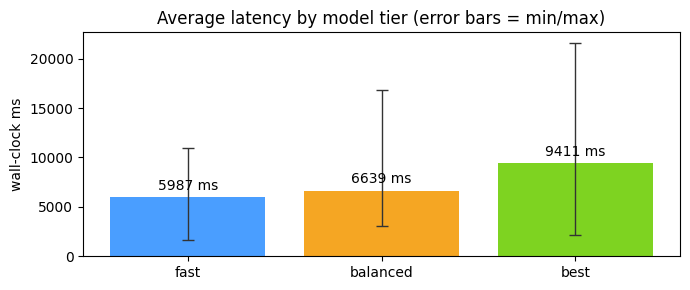

In [5]:
ok = [r for r in results if r["status"] == "ok"]
tier_order = ["fast", "balanced", "best"]
tier_stats = (
    df[df.status == "ok"]
    .groupby("model")["wall_ms"]
    .agg(["mean", "min", "max", "count"])
    .reindex(tier_order)
    .rename(columns={"mean": "avg_ms", "min": "min_ms", "max": "max_ms", "count": "n"})
)
display(tier_stats.style.format("{:.0f}", subset=["avg_ms", "min_ms", "max_ms"]))

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(tier_stats.index, tier_stats["avg_ms"], color=["#4a9eff", "#f5a623", "#7ed321"])
ax.errorbar(
    tier_stats.index,
    tier_stats["avg_ms"],
    yerr=[tier_stats["avg_ms"] - tier_stats["min_ms"], tier_stats["max_ms"] - tier_stats["avg_ms"]],
    fmt="none", color="#333", capsize=4, linewidth=1,
)
ax.set_ylabel("wall-clock ms")
ax.set_title("Average latency by model tier (error bars = min/max)")
ax.bar_label(bars, fmt="%.0f ms", padding=3)
plt.tight_layout()
plt.show()

## Latency by scenario tag

,avg_ms,min_ms,max_ms,n
tag,,,,
short_ctx,2425,1641,3019,3
tiny,3296,2131,4184,3
medium_ctx,4379,3674,5036,3
long_ctx,4627,4223,5012,3
code_ctx,13043,7122,21579,3
long_output,16306,10985,21070,3


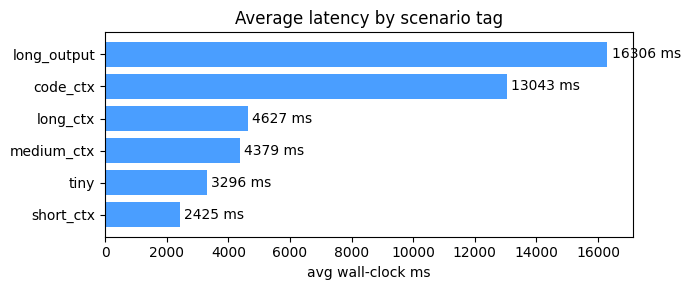

In [6]:
tag_rows = [
    {"tag": tag, "wall_ms": r["wall_ms"]}
    for r in ok
    for tag in r["tags"]
]
tag_df = pd.DataFrame(tag_rows)
tag_stats = tag_df.groupby("tag")["wall_ms"].agg(["mean", "min", "max", "count"]).sort_values("mean")
tag_stats.columns = ["avg_ms", "min_ms", "max_ms", "n"]
display(tag_stats.style.format("{:.0f}", subset=["avg_ms", "min_ms", "max_ms"]))

fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.barh(tag_stats.index, tag_stats["avg_ms"], color="#4a9eff")
ax.set_xlabel("avg wall-clock ms")
ax.set_title("Average latency by scenario tag")
ax.bar_label(bars, fmt="%.0f ms", padding=3)
plt.tight_layout()
plt.show()

## Full responses

In [7]:
for r in results:
    status = "✓" if r["status"] == "ok" else "✗"
    print(f"{status} {r['name']}  [{r['model']}]  wall={r['wall_ms']:.0f}ms  chars={r['response_chars']}")
    if r["status"] == "error":
        print(f"  ERROR: {r['error']}")
    else:
        for line in r["response"].splitlines():
            print(f"  {line}")
    print()

✓ tiny_haiku  [fast]  wall=4184ms  chars=10
  2 + 2 = 4.

✓ tiny_sonnet  [balanced]  wall=3574ms  chars=1
  4

✓ tiny_opus  [best]  wall=2131ms  chars=1
  4

✓ short_haiku  [fast]  wall=1641ms  chars=39
  A nimble fox jumps over a sleeping dog.

✓ short_sonnet  [balanced]  wall=3019ms  chars=40
  A quick brown fox leaps over a lazy dog.

✓ short_opus  [best]  wall=2616ms  chars=40
  A quick brown fox leaps over a lazy dog.

✓ medium_haiku  [fast]  wall=3674ms  chars=746
  AI has fundamentally transformed technology through breakthroughs in machine learning, including deep learning for vision/speech, transformers with attention mechanisms, and large language models trained on vast internet corpora. Key techniques like transfer learning, reinforcement learning, and natural language processing now enable machines to perform tasks once exclusive to humans, including understanding and generating human text. Modern approaches like prompt engineering and retrieval-augmented generation allow p